# Übung 6: Vektorisierung – Bag-of-Words, TF-IDF und N-Grams

Datensatz: `tweet_emotion_clean.parquet` – bereinigte Tweets mit Emotions-Label.

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

plt.rcParams["figure.figsize"] = (12, 5)

## 1 Daten laden

In [2]:
df = pl.read_parquet("../data/tweet_emotion_clean.parquet")
texts = df["content_clean"].to_list()
print(f"Anzahl Tweets: {len(texts):,}")
df.head()

Anzahl Tweets: 39,827


content_clean,emotion
str,str
"""i know i was listenin to bad h…","""empty"""
"""layin n bed with a headache ug…","""sadness"""
"""funeral ceremonygloomy friday""","""sadness"""
"""wants to hang out with friends…","""enthusiasm"""
"""we want to trade with someone …","""neutral"""


## 2 Bag-of-Words

Jeder Tweet wird in einen Zählvektor umgewandelt. Die Reihenfolge der Wörter spielt keine Rolle – nur wie oft jedes Wort vorkommt.

In [3]:
bow_vectorizer = CountVectorizer(stop_words="english", max_features=10_000)
X_bow = bow_vectorizer.fit_transform(texts)

print(f"Matrix-Größe:    {X_bow.shape}  (Dokumente × Token)")
print(f"Vokabular-Größe: {len(bow_vectorizer.vocabulary_):,}")
print(f"Speicherformat:  {type(X_bow).__name__}")

Matrix-Größe:    (39827, 10000)  (Dokumente × Token)
Vokabular-Größe: 10,000
Speicherformat:  csr_matrix


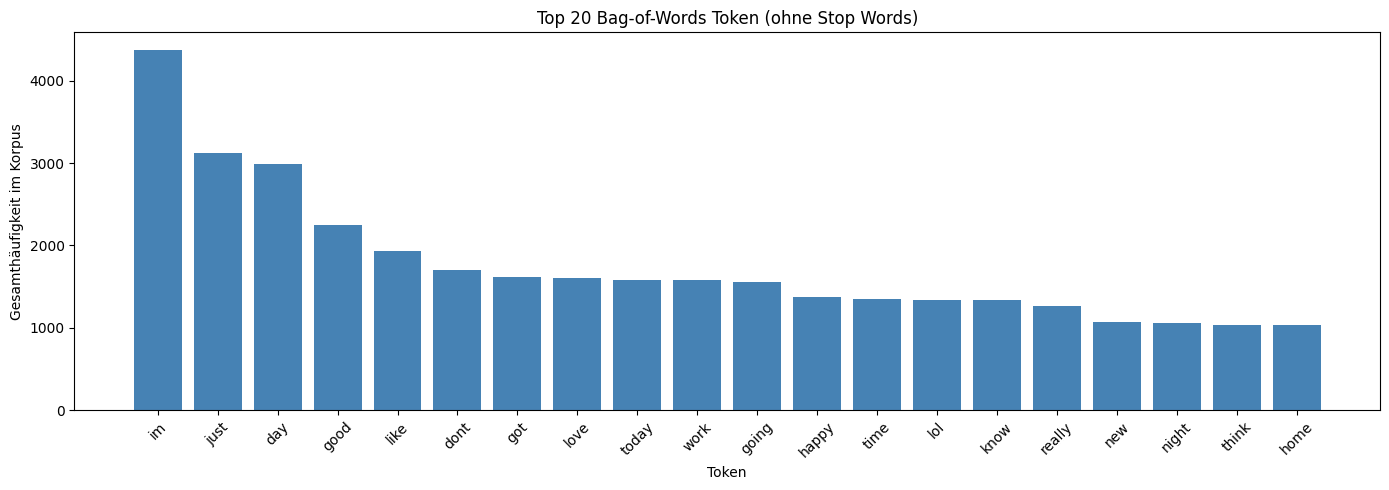

,token,count
4189,im,4370
4484,just,3129
2073,day,2990
3602,good,2243
4790,like,1928
2478,dont,1700
3627,got,1614
4951,love,1602
9057,today,1579
9813,work,1578


In [4]:
# Top 20 häufigste Token im gesamten Korpus
feature_names = bow_vectorizer.get_feature_names_out()
counts = X_bow.toarray().sum(axis=0)

bow_df = pd.DataFrame({"token": feature_names, "count": counts})
top20_bow = bow_df.sort_values("count", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top20_bow["token"], top20_bow["count"], color="steelblue")
ax.set_title("Top 20 Bag-of-Words Token (ohne Stop Words)")
ax.set_xlabel("Token")
ax.set_ylabel("Gesamthäufigkeit im Korpus")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../assets/barchart_bow_top20.png", dpi=150, bbox_inches="tight")
plt.show()
top20_bow

## 3 TF-IDF

TF-IDF gewichtet Wörter, die in einem Dokument häufig vorkommen, aber im gesamten Korpus selten sind – das sind oft die bedeutsamen, emotionsspezifischen Wörter.

In [5]:
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=10_000)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

print(f"Matrix-Größe:    {X_tfidf.shape}  (Dokumente × Token)")
print(f"Vokabular-Größe: {len(tfidf_vectorizer.vocabulary_):,}")

Matrix-Größe:    (39827, 10000)  (Dokumente × Token)
Vokabular-Größe: 10,000


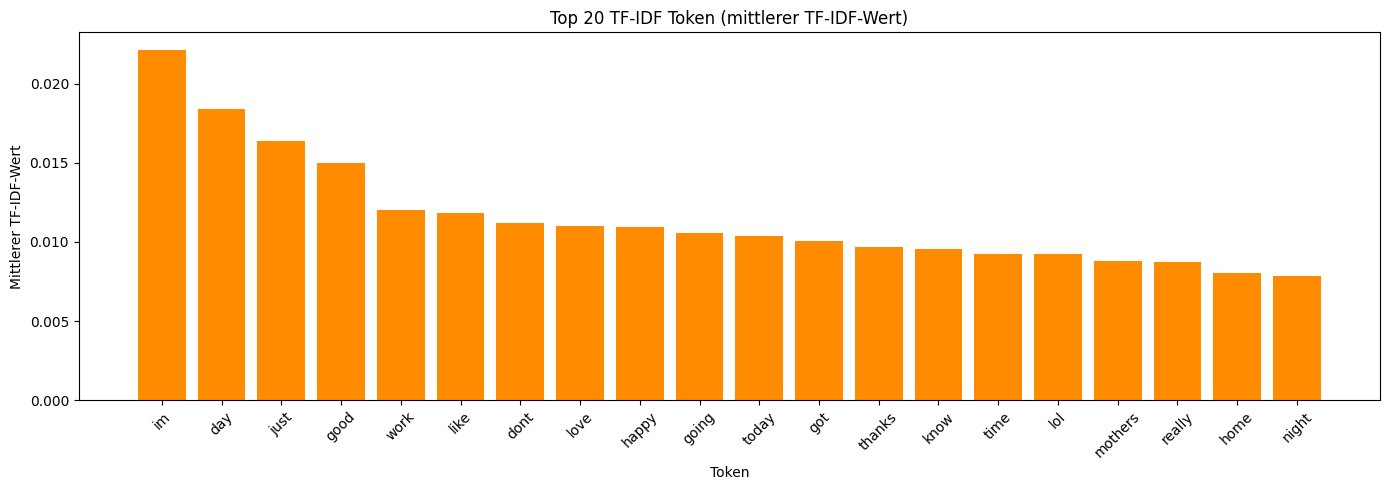

,token,mean_tfidf
4189,im,0.022145
2073,day,0.018434
4484,just,0.016351
3602,good,0.015020
9813,work,0.012044
4790,like,0.011819
2478,dont,0.011222
4951,love,0.011018
3825,happy,0.010974
3591,going,0.010588


In [6]:
# Top 20 Token nach mittlerem TF-IDF-Wert über alle Dokumente
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
mean_tfidf = X_tfidf.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({"token": tfidf_feature_names, "mean_tfidf": mean_tfidf})
top20_tfidf = tfidf_df.sort_values("mean_tfidf", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(top20_tfidf["token"], top20_tfidf["mean_tfidf"], color="darkorange")
ax.set_title("Top 20 TF-IDF Token (mittlerer TF-IDF-Wert)")
ax.set_xlabel("Token")
ax.set_ylabel("Mittlerer TF-IDF-Wert")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../assets/barchart_tfidf_top20.png", dpi=150, bbox_inches="tight")
plt.show()
top20_tfidf

## 4 N-Grams

N-Grams erweitern BoW um Wortsequenzen – so kann der Vektorisierer auch Ausdrücke wie "feel good" oder "not happy" erkennen.

In [7]:
# Bigrams (2-Wort-Sequenzen)
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=20_000)
X_bigram = bigram_vectorizer.fit_transform(texts)

bigram_names = bigram_vectorizer.get_feature_names_out()
bigram_counts = X_bigram.toarray().sum(axis=0)

bigram_df = pd.DataFrame({"bigram": bigram_names, "count": bigram_counts})
top8_bigrams = bigram_df.sort_values("count", ascending=False).head(8)

print("Top 8 Bigramme:")
print(top8_bigrams.to_string(index=False))

Top 8 Bigramme:
       bigram  count
  mothers day    884
happy mothers    638
     just got    312
 good morning    254
     im going    244
    dont know    237
     im sorry    168
    feel like    166


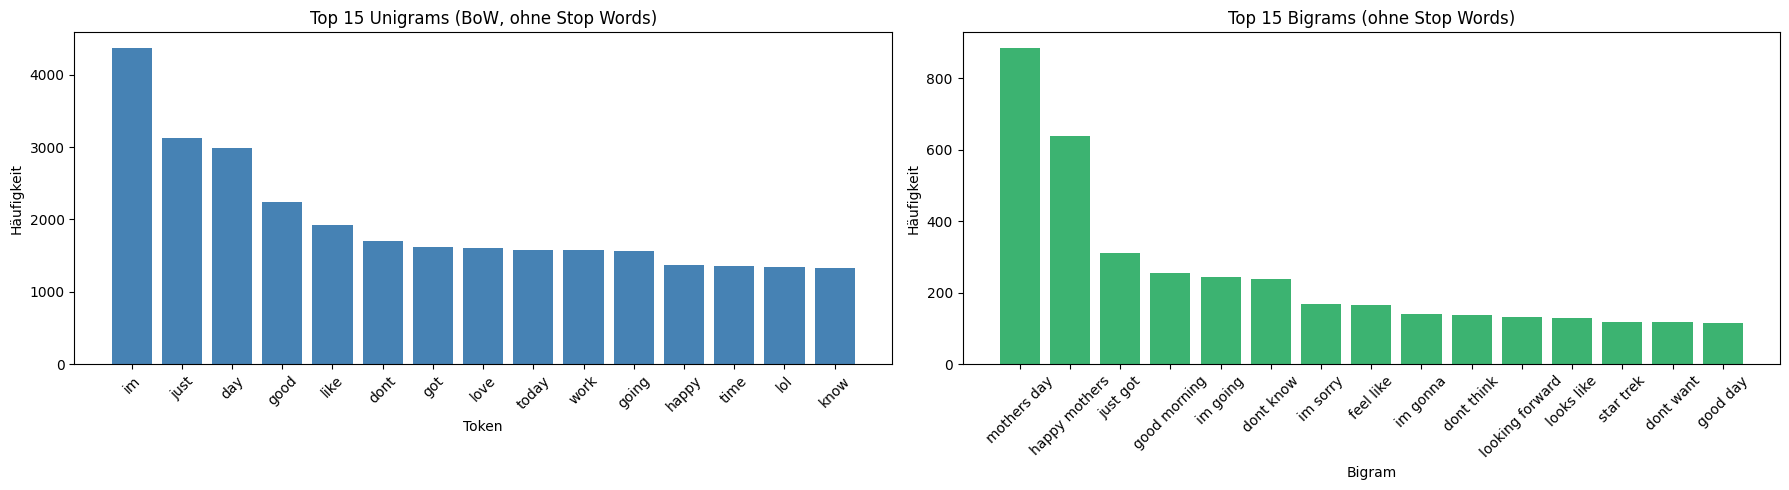

In [8]:
# Vergleich: Unigrams vs. Bigrams – Top 15 je
top15_uni = bow_df.sort_values("count", ascending=False).head(15)
top15_bi  = bigram_df.sort_values("count", ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(top15_uni["token"], top15_uni["count"], color="steelblue")
axes[0].set_title("Top 15 Unigrams (BoW, ohne Stop Words)")
axes[0].set_xlabel("Token")
axes[0].set_ylabel("Häufigkeit")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(top15_bi["bigram"], top15_bi["count"], color="mediumseagreen")
axes[1].set_title("Top 15 Bigrams (ohne Stop Words)")
axes[1].set_xlabel("Bigram")
axes[1].set_ylabel("Häufigkeit")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../assets/barchart_ngrams_vergleich.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 Erkenntnisse

**Bag-of-Words:**
- Einfach und effizient, aber ignoriert die Reihenfolge der Wörter vollständig.
- Mit `stop_words='english'` dominieren emotionsrelevante Wörter wie "feel", "love", "day".
- Die Matrix ist sehr dünn besetzt (sparse): 39.827 Dokumente × 10.000 Token, aber die meisten Einträge sind 0.

**TF-IDF:**
- Gewichtet Wörter, die in einzelnen Dokumenten bedeutsam sind, aber insgesamt selten vorkommen.
- Häufige Wörter wie "im" oder "day" erhalten kleinere TF-IDF-Werte als seltene, spezifische Ausdrücke.
- Besser geeignet als reines BoW für Klassifikationsaufgaben, da bedeutungslose häufige Wörter automatisch abgewertet werden.

**N-Grams:**
- Bigramme wie "feel like", "new year", "good morning" erfassen Bedeutung, die Unigrams nicht sehen.
- Negationen ("not happy", "dont feel") werden als eigene Token erkannt.
- Der Nachteil: das Vokabular wächst drastisch – bei Bigrammen um ein Vielfaches gegenüber Unigrams.